In [1]:
from joblib import load
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

In [2]:
# Step 1: Load data
aggregated_metrics = load("/home/hanwu/AnalogDesignAuto/AnalogDesignAuto_MultiAgent/custom_env/run_test/sum_specs_3.joblib")  # Adjust the path as necessary

# Step 2: Data cleaning
df = pd.DataFrame(aggregated_metrics)
print(f"Original data groups: {df.shape[0]}")

# New logic for dynamic data cleaning
for column in df.columns:
    original_count = df.shape[0]
    if column == 'pwr':
        # Delete rows where 'pwr' is 1
        df = df[df[column] != 1]
    else:
        # Delete rows where other columns are 0
        df = df[df[column] != 0]
    cleaned_count = df.shape[0]
    print(f"Deleted {original_count - cleaned_count} rows from '{column}' due to cleaning criteria.")

# Print the original and cleaned data counts for comparison
print(f"Cleaned data groups: {df.shape[0]}")

Original data groups: 513391
Deleted 7480 rows from 'phaseMargin' due to cleaning criteria.
Deleted 0 rows from 'gainBandWidth' due to cleaning criteria.
Deleted 412 rows from 'pwr' due to cleaning criteria.
Cleaned data groups: 505499


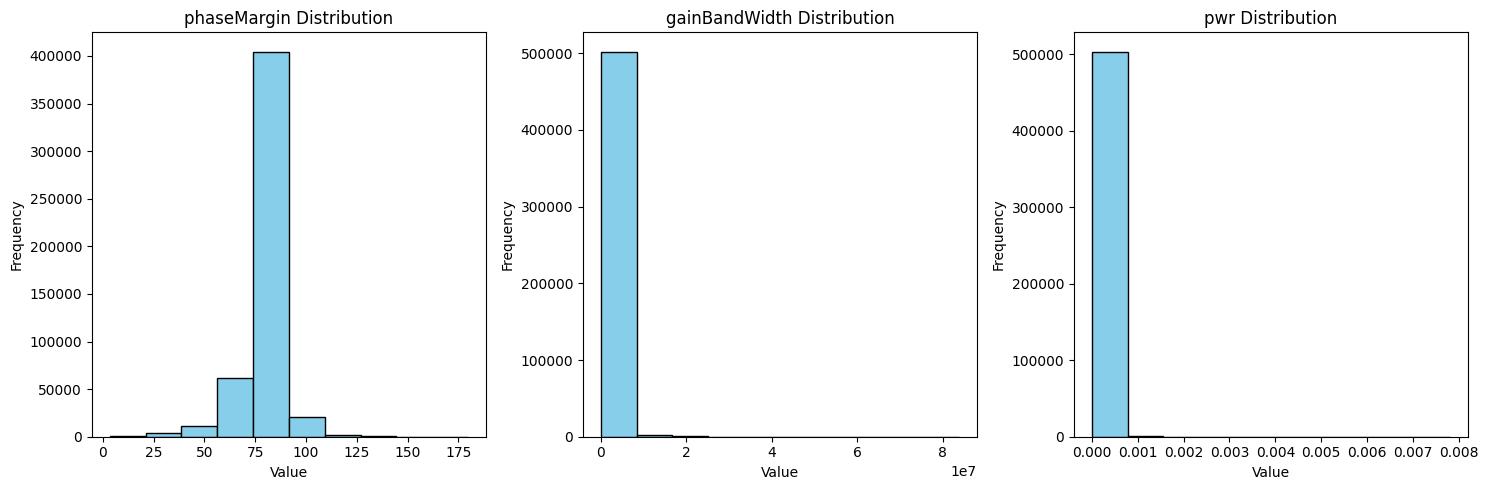

FloatRangeSlider(value=(3.50619, 179.7261), description='phaseMargin:', max=179.7261, min=3.50619)

FloatRangeSlider(value=(1.014083, 83778140.0), description='gainBandWidth:', max=83778140.0, min=1.014083)

FloatRangeSlider(value=(1.80703e-06, 0.00780221), description='pwr:', max=0.00780221, min=1.80703e-06)

interactive(children=(FloatRangeSlider(value=(3.50619, 179.7261), description='phaseMargin:', max=179.7261, mi…

In [3]:
# Step 3: Interactive analysis
def update_charts(btn):
    conditions = []
    for column in df.columns:
        try:
            min_val = float(inputs[f"{column}_min"].value)
            max_val = float(inputs[f"{column}_max"].value)
            conditions.append((df[column] >= min_val) & (df[column] <= max_val))
        except ValueError:
            print(f"Invalid input for {column}. Please enter valid numbers.")
            return
    filtered_df = df[np.all(conditions, axis=0)]
    
    plt.clf()  # Clear the current figure to prevent overlapping of plots
    if not filtered_df.empty:
        fig, axes = plt.subplots(1, len(df.columns), figsize=(5 * len(df.columns), 5))
        if len(df.columns) == 1:
            axes = [axes]  # Make it iterable if there's only one column
        for i, column in enumerate(df.columns):
            axes[i].hist(filtered_df[column], bins=10, color='skyblue', edgecolor='black')
            axes[i].set_title(f'Filtered {column} Distribution')
            axes[i].set_xlabel('Value')
            axes[i].set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print("No data available within the specified range. Please adjust the filters.")

# Function to reset filters to initial min/max values
def reset_filters(btn):
    for column in df.columns:
        inputs[f"{column}_min"].value = str(df[column].min())
        inputs[f"{column}_max"].value = str(df[column].max())

# Create manual input fields for min/max values and buttons
inputs = {}
for column in df.columns:
    min_input = widgets.Text(value=str(df[column].min()), description=f'Min {column}:')
    max_input = widgets.Text(value=str(df[column].max()), description=f'Max {column}:')
    inputs[f"{column}_min"] = min_input
    inputs[f"{column}_max"] = max_input

for input_field in inputs.values():
    display(input_field)

update_button = widgets.Button(description="Update Charts")
update_button.on_click(update_charts)
display(update_button)

reset_button = widgets.Button(description="Reset Filters")
reset_button.on_click(reset_filters)
display(reset_button)